In [1]:
import sys, os
os.chdir('..')  # set CWD to project root
sys.path.insert(0, 'src')

import pandas as pd

from etl import *
from regression import *
from sims_engine import *

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
CONFIG = {
    'elo_date': '2026-04-08',  # date for elo ratings from clubelo.com
    'opta_date': '2026-04-08',  # date for elo ratings from the opta -> clubelo regression; elo_date from day X is before the games are played, for opta it depends
    'number_of_sims': 20000,
    'league_id': 106,
    'season': 2025,
    'head_size': 36,
    'country_code_elo': None,  # use this attr. to use elo ratings from clubelo.com
    'country_code_api': 'POL',  # use this attr. to use elo ratings from the opta -> clubelo regression
    'stdev': 0,
    'update_fixtures': True,
    'is_european_league': False,
    'round_no': 27,
    'point_deductions': {'Lechia Gdansk': 5}
}
code = CONFIG['country_code_elo'] if CONFIG['country_code_elo'] is not None else CONFIG['country_code_api']
CONFIG['sorting_order'] = get_sorting_order_for_country_code(code)

In [5]:
# download_elo_data(CONFIG['elo_date'])

18 ELO teams matched.
24 Opta teams matched.
13 unmatched Opta teams found, see transformed/opta/opta_unmatched_map.csv:
33 unmatched Opta teams found, see transformed/opta/opta_unmatched_elo_df.csv:
18 teams used for regression.
0.907 R^2 score
y = 28.22 * x + -795.85


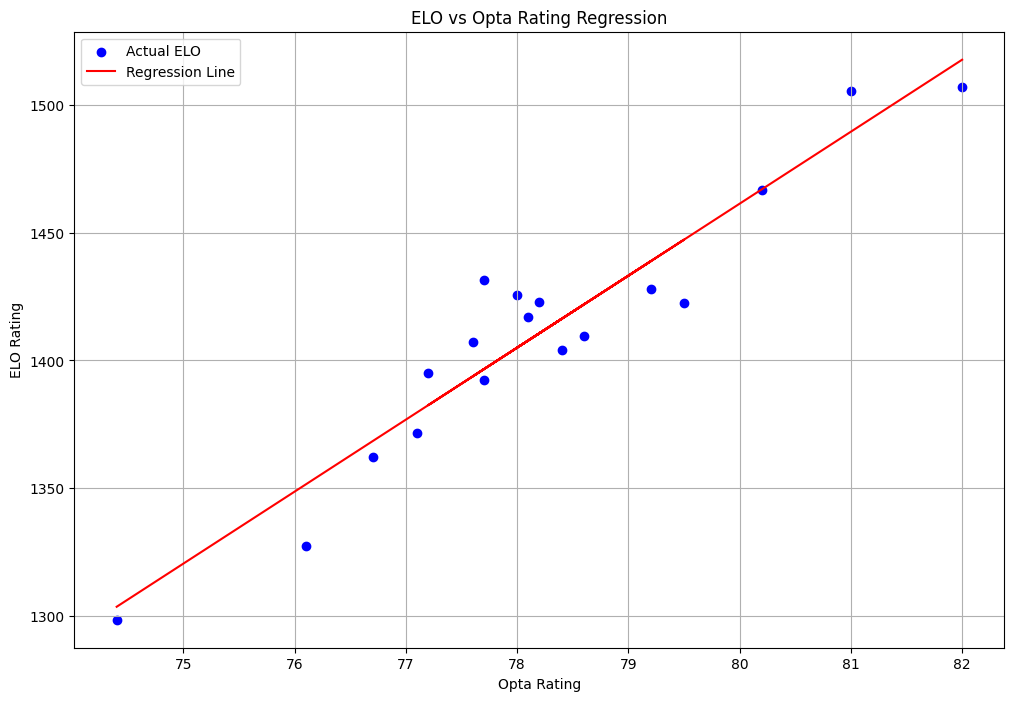

In [6]:
main_regression(**CONFIG)

In [7]:
standings_df, fixtures_matrix = build_historical_standings_table_after_at_most_n_rounds(**CONFIG)
standings_df.head(CONFIG['head_size'])

,Club,Elo,Matches played,Wins,Draws,Losses,Goals for,Goals against,Goal difference,Goals away,Points,Random order,H2H
1,Lech Poznan,1517.88,27,12,9,6,46,37,9,17,45,12,1
2,Gornik Zabrze,1447.34,27,12,6,9,39,32,7,12,42,8,1
3,Jagiellonia,1467.09,27,11,9,7,43,34,9,14,42,4,2
4,Zaglebie Lubin,1410.66,27,11,8,8,41,33,8,17,41,2,1
5,Wisla Plock,1379.62,27,10,9,8,28,26,2,13,39,9,1
6,Raków Częstochowa,1489.66,27,11,6,10,36,34,2,22,39,16,2
7,GKS Katowice,1421.94,27,12,3,12,36,35,1,15,39,5,3
8,Motor Lublin,1396.55,27,9,11,7,36,39,-3,17,38,14,1
9,Lechia Gdansk,1416.30,27,12,6,9,55,50,5,22,37,3,1
10,Cracovia Krakow,1407.83,27,9,9,9,31,31,0,14,36,13,1


In [8]:
CONFIG['update_fixtures'] = False

In [9]:
float(round(standings_df['Points'].sum() / standings_df['Matches played'].sum(), 2))

1.35

In [10]:
sample_season = simulate_season_after_n_rounds(**CONFIG, standings_df=standings_df)
sample_season.head(CONFIG['head_size'])

,Club,Elo,Matches played,Wins,Draws,Losses,Goals for,Goals against,Goal difference,Goals away,Points,Random order,H2H
1,Jagiellonia,1467.09,34,16,10,8,54,37,17,19,58,15,1
2,Lech Poznan,1517.88,34,16,9,9,54,43,11,21,57,11,1
3,Zaglebie Lubin,1410.66,34,15,9,10,50,38,12,19,54,3,1
4,Motor Lublin,1396.55,34,13,12,9,45,44,1,20,51,4,1
5,Piast Gliwice,1405.01,34,14,8,12,45,39,6,23,50,13,1
6,Wisla Plock,1379.62,34,13,10,11,35,33,2,16,49,14,1
7,Gornik Zabrze,1447.34,34,14,7,13,44,41,3,15,49,5,2
8,GKS Katowice,1421.94,34,15,4,15,43,42,1,17,49,10,3
9,Raków Częstochowa,1489.66,34,14,7,13,43,41,2,24,49,9,4
10,Korona Kielce,1393.73,34,12,10,12,43,39,4,20,46,16,1


In [11]:
float(round(sample_season['Points'].sum() / sample_season['Matches played'].sum(), 2))

1.36

In [12]:
simulate_odds(**CONFIG, standings_df=standings_df).head(CONFIG['head_size'])

,Home Team,Away Team,Odds H,Odds D,Odds A
0,GKS Katowice,Wisla Plock,2.12,3.66,3.93
1,Raków Częstochowa,Widzew Łódź,1.76,4.19,5.15
2,Gornik Zabrze,Cracovia Krakow,2.13,3.65,3.89
3,Jagiellonia,Lech Poznan,2.71,3.43,2.94
4,Nieciecza,Piast Gliwice,3.15,3.45,2.55
5,Radomiak Radom,Motor Lublin,2.45,3.48,3.29
6,Pogon Szczecin,Legia Warszawa,2.65,3.43,3.02
7,Lechia Gdansk,Korona Kielce,2.23,3.58,3.68
8,Arka Gdynia,Zaglebie Lubin,2.78,3.42,2.87


In [13]:
# full table sim
results = run_full_table_sims(**CONFIG, standings_df=standings_df, fixtures_matrix=fixtures_matrix)
results.head(CONFIG['head_size'])

100%|██████████| 20000/20000 [08:53<00:00, 37.48it/s]


20000 simulations


,Club,Elo,xPts,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
1,Lech Poznan,1517.88,57.40,69.5,17.4,6.8,3.1,1.6,0.8,0.4,0.2,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Jagiellonia,1467.09,52.37,10.4,22.1,17.7,14.3,11.0,8.5,6.0,4.0,2.5,1.6,0.9,0.5,0.3,0.1,0.1,0.0,0.0,0.0
3,Gornik Zabrze,1447.34,52.28,8.8,22.2,19.6,14.2,11.2,7.9,5.4,4.2,2.7,1.7,1.1,0.6,0.3,0.2,0.0,0.0,0.0,0.0
4,Zaglebie Lubin,1410.66,50.83,4.6,13.8,15.4,14.8,13.3,10.6,8.2,6.1,4.7,3.4,2.1,1.3,0.8,0.5,0.2,0.1,0.0,0.0
5,Raków Częstochowa,1489.66,50.48,3.0,11.0,14.5,14.9,13.1,11.0,8.9,6.9,5.1,3.8,2.9,2.2,1.4,0.8,0.4,0.2,0.0,0.0
6,GKS Katowice,1421.94,48.52,1.5,4.1,7.0,9.4,10.9,11.9,11.0,10.4,8.7,7.4,6.3,4.5,3.2,2.0,1.1,0.5,0.1,0.0
7,Wisla Plock,1379.62,48.11,1.0,3.9,6.4,8.5,10.1,10.8,11.3,10.6,9.5,7.9,6.6,4.9,3.7,2.5,1.4,0.8,0.1,0.0
8,Lechia Gdansk,1416.30,46.73,0.4,1.7,3.8,5.1,7.3,8.2,9.7,10.2,10.0,9.7,8.8,7.6,6.3,4.9,3.6,2.0,0.8,0.0
9,Motor Lublin,1396.55,46.55,0.5,1.6,2.9,4.8,6.2,7.6,9.0,9.8,10.4,10.3,9.3,8.6,7.2,5.4,3.8,1.9,0.6,0.0
10,Cracovia Krakow,1407.83,45.86,0.2,0.8,2.3,3.7,4.8,6.7,7.9,8.9,9.9,9.6,9.8,8.9,7.9,6.9,6.0,3.9,1.6,0.0


In [14]:
# top 1, 2, 3, 4 sim
results = run_top_n_sims(**CONFIG, standings_df=standings_df, fixtures_matrix=fixtures_matrix, top_n=[1, 2, 3, 4])
results.head(CONFIG['head_size'])

100%|██████████| 20000/20000 [09:41<00:00, 34.38it/s]


20000 simulations
Top N: [1, 2, 3, 4]


,Club,Elo,xPts,Top 1 %,Top 1 Odds,Top 2 %,Top 2 Odds,Top 3 %,Top 3 Odds,Top 4 %,Top 4 Odds
1,Lech Poznan,1517.88,57.33,68.6,1.46,86.7,1.15,93.7,1.07,96.8,1.03
2,Jagiellonia,1467.09,52.41,10.6,9.43,32.8,3.05,50.4,1.98,65.2,1.53
3,Gornik Zabrze,1447.34,52.28,8.7,11.49,30.8,3.25,50.2,1.99,65.2,1.53
4,Zaglebie Lubin,1410.66,50.82,4.9,20.41,18.1,5.52,33.6,2.98,48.4,2.07
5,Raków Częstochowa,1489.66,50.51,3.3,30.3,14.3,6.99,29.0,3.45,43.2,2.31
6,GKS Katowice,1421.94,48.56,1.6,62.5,5.9,16.95,12.9,7.75,22.3,4.48
7,Wisla Plock,1379.62,48.11,1.3,76.92,5.0,20.0,11.4,8.77,20.1,4.98
8,Lechia Gdansk,1416.30,46.73,0.4,250.0,2.1,47.62,5.6,17.86,10.7,9.35
9,Motor Lublin,1396.55,46.56,0.4,250.0,1.9,52.63,5.2,19.23,9.9,10.1
10,Cracovia Krakow,1407.83,45.86,0.2,500.0,1.0,100.0,3.1,32.26,6.8,14.71


In [15]:
# bottom 1, 3 sim
results = run_top_n_sims(**CONFIG, standings_df=standings_df, fixtures_matrix=fixtures_matrix, top_n=[1, 3], reverse=True)
results.head(CONFIG['head_size'])

100%|██████████| 20000/20000 [07:37<00:00, 43.70it/s]

20000 simulations
Top N: [1, 3]
Reverse: TRUE


,Club,Elo,xPts,Top 1 %,Top 1 Odds,Top 3 %,Top 3 Odds
1,Nieciecza,1303.43,32.35,87.2,1.15,98.4,1.02
2,Widzew Łódź,1368.33,39.19,6.7,14.93,62.0,1.61
3,Arka Gdynia,1351.40,40.62,3.9,25.64,48.5,2.06
4,Legia Warszawa,1438.87,43.36,0.8,125.0,15.7,6.37
5,Radomiak Radom,1382.44,42.51,0.7,142.86,23.4,4.27
6,Pogon Szczecin,1396.55,42.63,0.5,200.0,22.9,4.37
7,Piast Gliwice,1405.01,44.73,0.1,1000.0,10.1,9.9
8,Korona Kielce,1393.73,44.96,0.1,1000.0,6.8,14.71
9,Jagiellonia,1467.09,52.40,0.0,N/A,0.0,N/A
10,Lech Poznan,1517.88,57.38,0.0,N/A,0.0,N/A


football-md.com

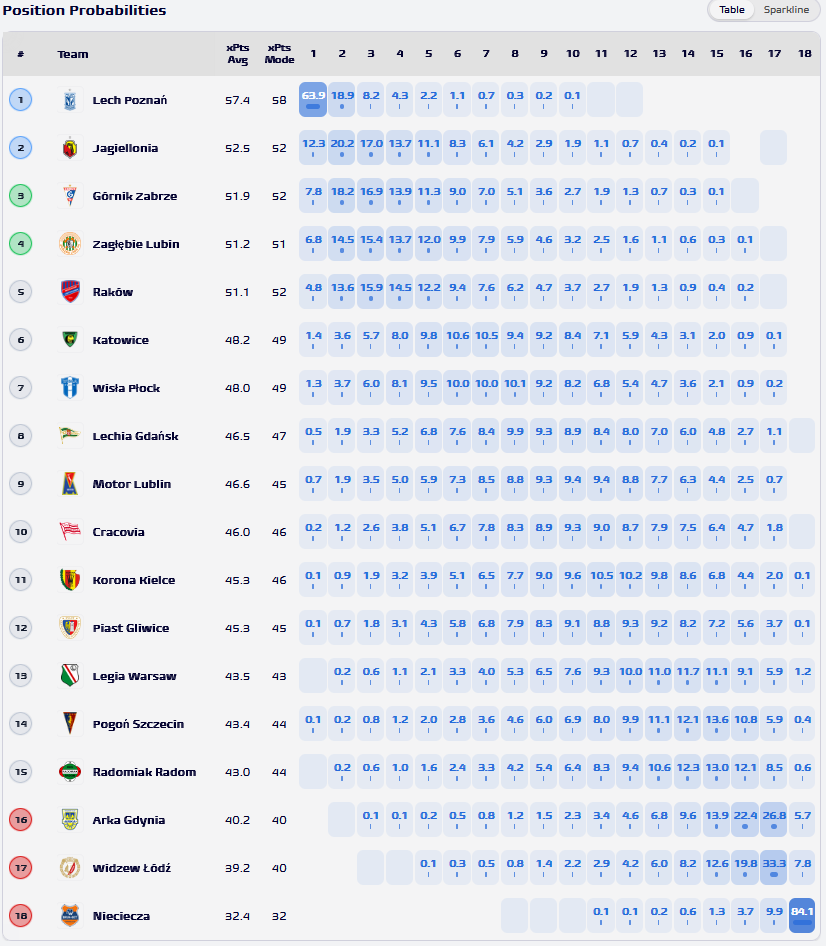

symuliga.pl

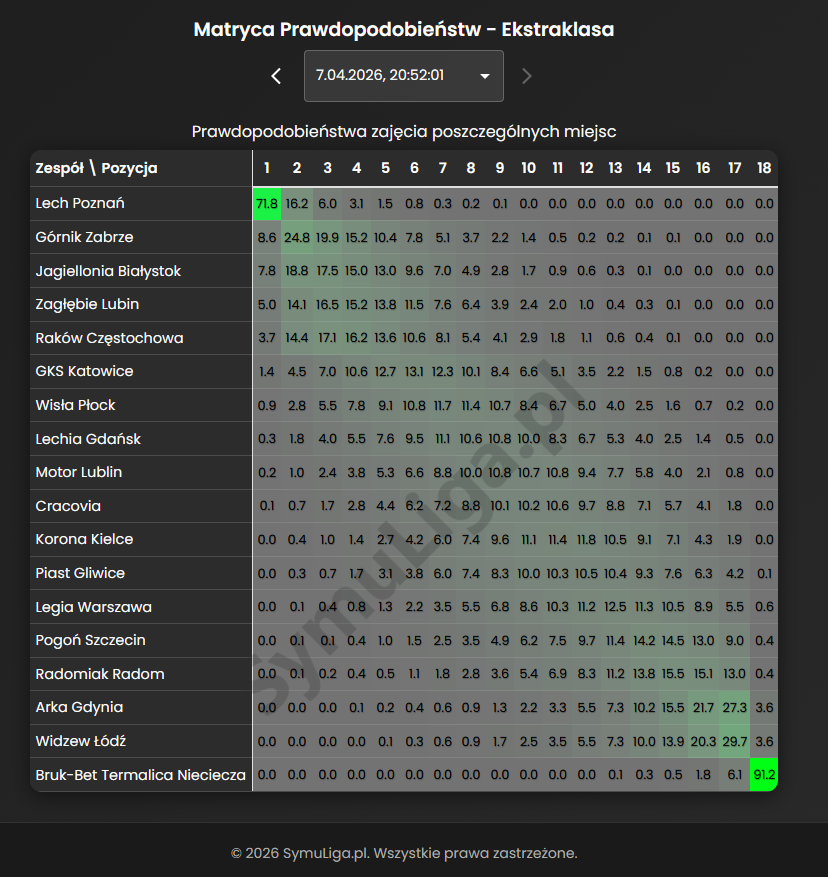

Winner odds

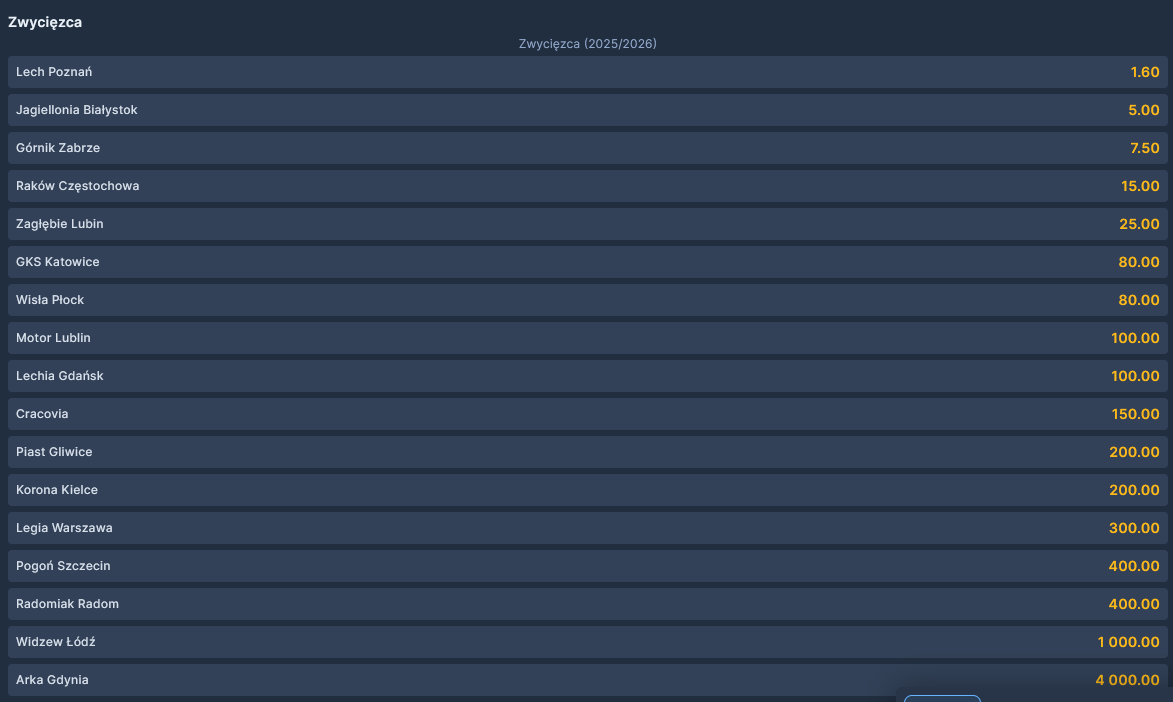

Top 2 odds

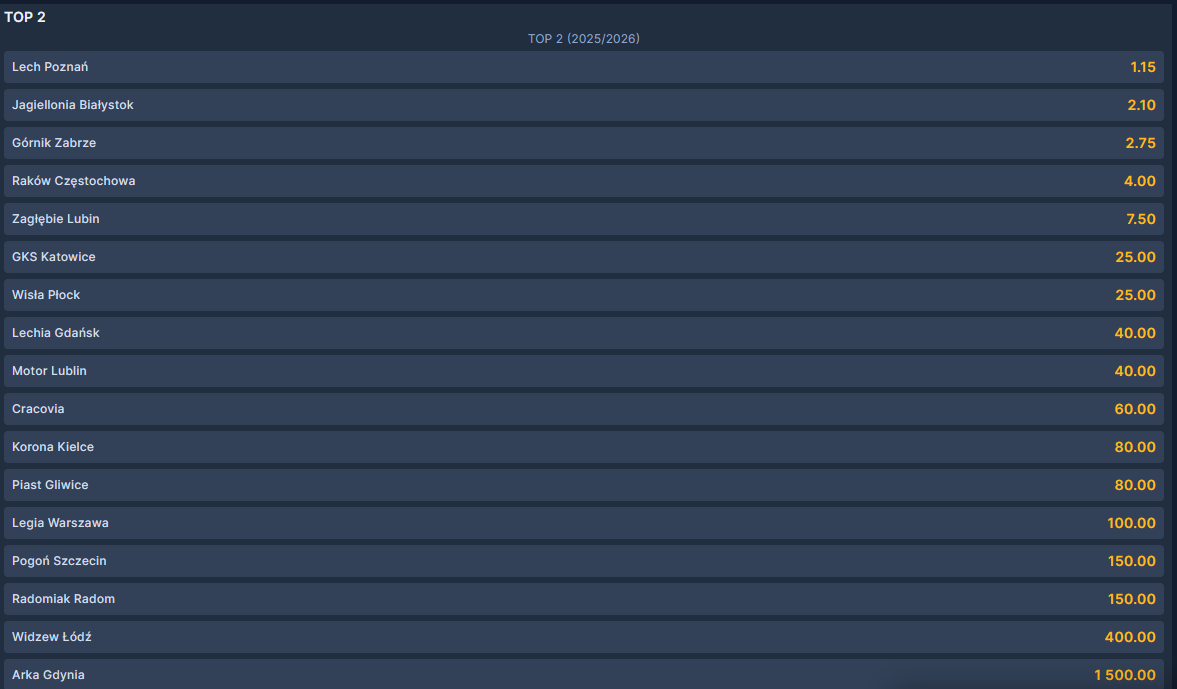

Top 3 odds

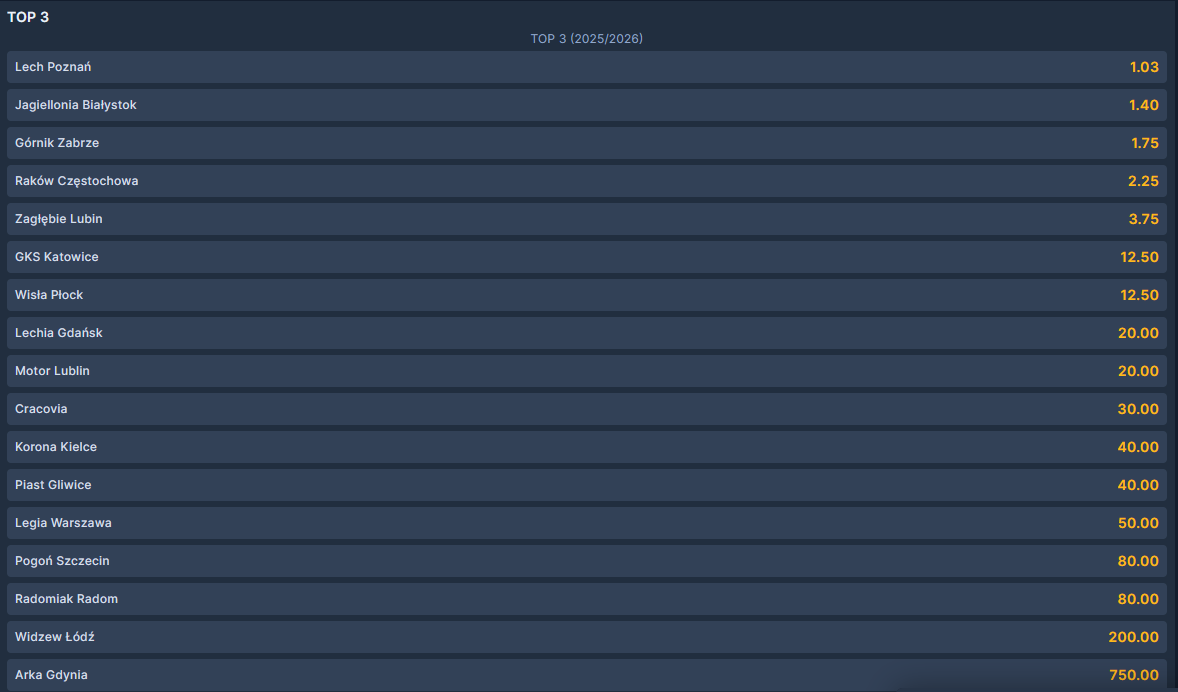

Top 4 odds

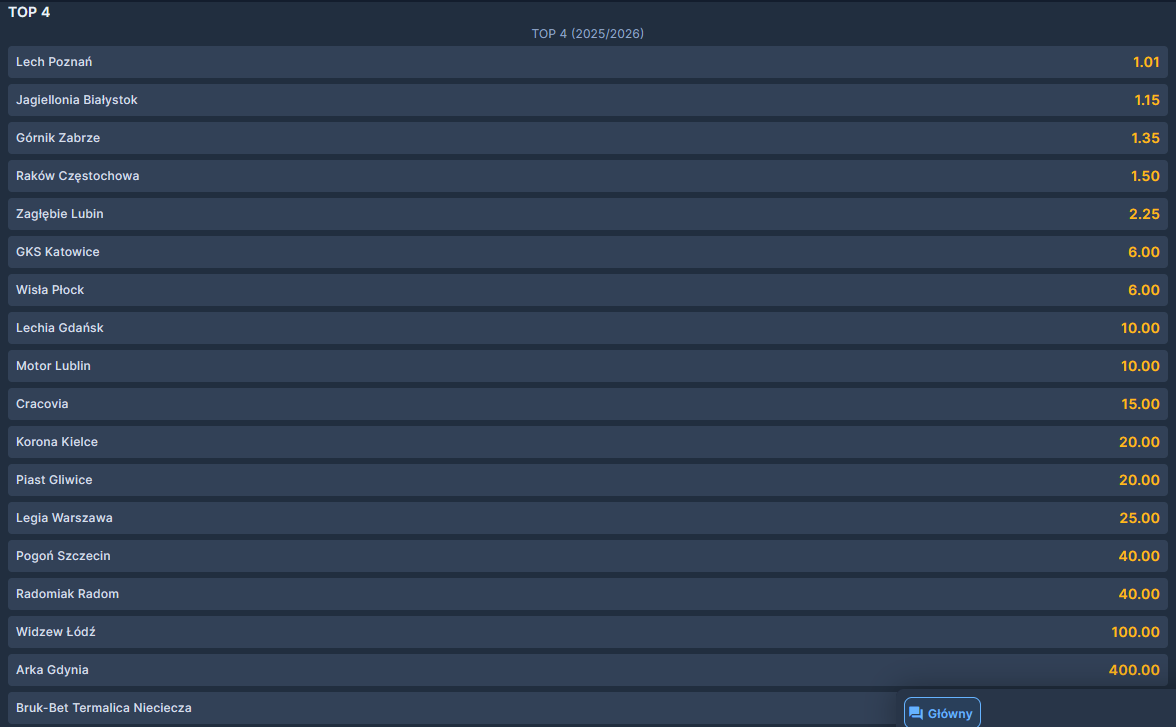

Relegation odds

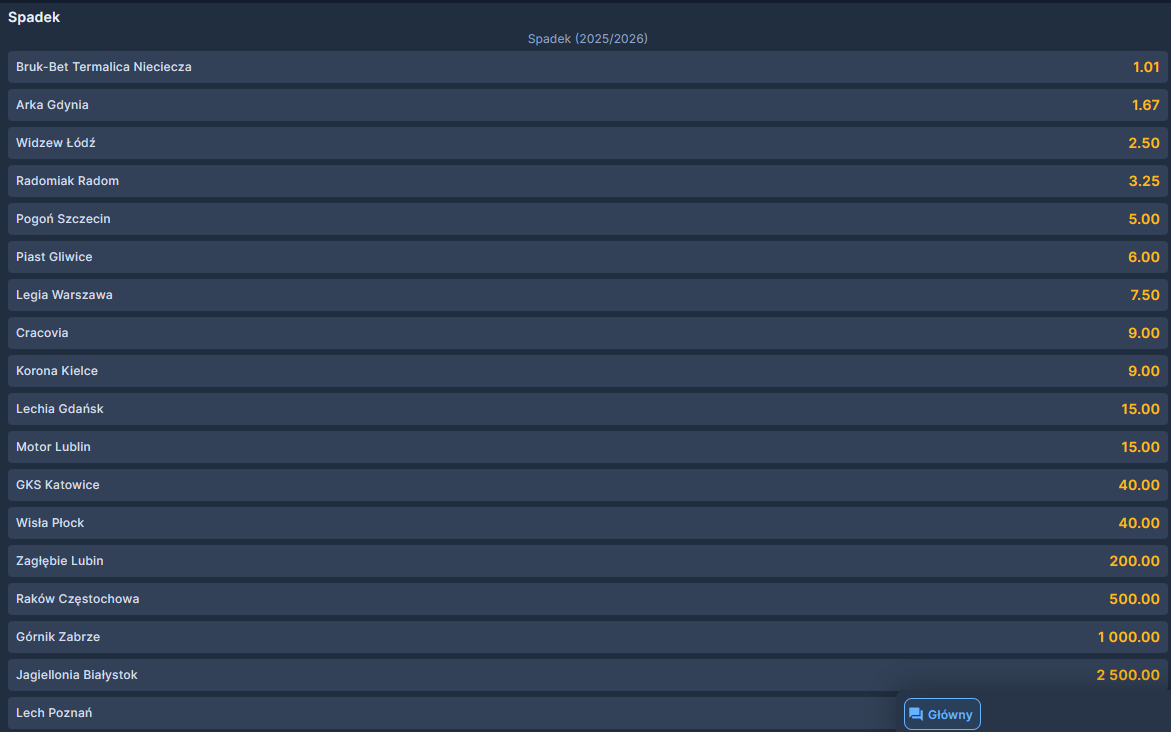

**Observations**

Note: all teams played 27 out of 34 matches - quite late in the season that's additionally rich in surprises

- all 3 models slightly favour Lech Poznań [1], Zagłębie Lubin [5], and GKS Katowice [6] in comparison to the bookmaker's implied odds. Interestingly, each model gives 1.4-1.5% for GKS. In contrast, Jagiellonia [2], Górnik Zabrze [3], and Raków [4] are quite significantly disfavored.

- all 3 models correctly predict that Legia [13] is more likely to finish last than Pogoń [14] and Radomiak [14], but less likely to be relegated than them

- symuliga's model gives the highest probabilities to Lech Poznań to win and for Nieciecza to finish last out of 3 models. In contrast, football-md's model gives them the lowest probabilities.

| Event | Symuliga | Football-MD | My Model | Bookie implied | Bookie vig-adjusted
|-------|----------|-------------|----------|----------|----------|
| Lech to finish first | 71.8% | 63.9% | 69.5% | 62.5% | 55.0%
| Nieciecza to finish last | 91.2% | 84.1% | 87.1% | N/A | N/A
| Zagłębie to finish in top 3 | 35.6% | 36.7% | 33.8% | 26.7% | 23.8%
| Jagiellonia to finish first | 7.8% | 12.3% | 10.4% | 20.0% | 17.6%
| Raków to finish in top 3 | 35.2% | 34.3% | 28.5% | 44.4% | 39.7%

- both models find Widzew Łódź [16] significantly more likely to be relegated than what the bookie odds would imply. The opposite takes place in case of Arka Gdynia [17], Piast Gliwice [11] and Korona Kielce [11], Cracovia [10] and Lechia Gdańsk [9].

*numbers in brackets are ordered in line with teams' implied odds to win the league by the bookie

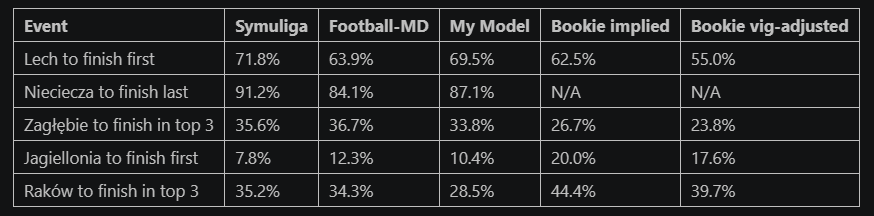

Gemini's courtesy script

```import pandas as pd

data = [
    ("Lech Poznań", 1.60),
    ("Jagiellonia Białystok", 5.00),
    ("Górnik Zabrze", 7.50),
    (...)
]

df = pd.DataFrame(data, columns=["Team", "Odds"])
df["Implied Prob"] = 1 / df["Odds"]
overround = df["Implied Prob"].sum()
df["Real Prob"] = (df["Implied Prob"] / overround) * 100

print(f"Overround: {overround}")
print(df[["Team", "Odds", "Implied Prob", "Real Prob"]])```